# Bilayer Graphene: Band fitting + trigonal warping
In this notebook we run the main DFT calculations, fit the TB bands to the DFT bands, and see if we can observe trigonal warping.


In [1]:
from dft_ab import run_dft_ab
from gpaw import restart
from gpaw.new.ase_interface import ASECalculator
import ase

In [2]:
filename = 'ab.gpw'
filepath = '../gpw/' + filename


Run the cell below to run DFT. Only need to run it once to generate the `.gpw` file, if not already there!

In [3]:
run_dft_ab(filename)

Exception: Specified already exists! Delete it or change filename

## Extract bands from DFT

In [ ]:
atoms, calc = restart(filepath)
atoms: ase.atoms.Atoms # for hints
calc: ASECalculator


In [5]:
import extract_pi_dft_bands
# extract the pi bands
extract_pi_dft_bands.save_pi_dft_bands(atoms, calc, path=['G', 'M', 'K', 'G'])

[[ 0.          0.          0.        ]
 [ 0.07512178 -0.04337158  0.        ]
 [ 0.15024355 -0.08674315  0.        ]
 [ 0.22536533 -0.13011473  0.        ]
 [ 0.3004871  -0.17348631  0.        ]
 [ 0.37560888 -0.21685789  0.        ]
 [ 0.45073065 -0.26022946  0.        ]
 [ 0.52585243 -0.30360104  0.        ]
 [ 0.6009742  -0.34697262  0.        ]
 [ 0.67609598 -0.3903442   0.        ]
 [ 0.75121776 -0.43371577  0.        ]
 [ 0.82633953 -0.47708735  0.        ]
 [ 0.90146131 -0.52045893  0.        ]
 [ 0.97658308 -0.56383051  0.        ]
 [ 1.05170486 -0.60720208  0.        ]
 [ 1.12682663 -0.65057366  0.        ]
 [ 1.20194841 -0.69394524  0.        ]
 [ 1.27707018 -0.73731681  0.        ]
 [ 1.23450118 -0.8110485   0.        ]
 [ 1.19193217 -0.88478018  0.        ]
 [ 1.14936317 -0.95851186  0.        ]
 [ 1.10679416 -1.03224354  0.        ]
 [ 1.06422515 -1.10597522  0.        ]
 [ 1.02165615 -1.1797069   0.        ]
 [ 0.97908714 -1.25343859  0.        ]
 [ 0.93651814 -1.32717027

In [6]:
kpts, E_pi, idx_pi, EF, sp_idx, sp_kpts = extract_pi_dft_bands.load_pi_dft_bands()

In [7]:
sp_kpts

{'Γ': array([0., 0.]),
 'K': array([ 0.85138012, -1.47463363]),
 'M': array([ 1.27707018, -0.73731681])}

## Tight-binding fit

Generate the 3D plot from the tight binding.

In [8]:
import tb_bands
#from tb_bands import TBBandManager
import importlib
import numpy as np
importlib.reload(tb_bands)

theta0 = np.array([
            4,#3.1,  # gamma0
            1,#0.39,  # gamma1
            0.315,  # gamma3
            0.044,  # gamma4
            0.0, 0.0, 0.0, 0.0  # epsA1, epsB1, epsA2, epsB2
        ])
manager = tb_bands.TBBandManager(atoms)

manager.create_3d_plot(theta0, kpts, sp_idx, sp_kpts)


[[-1.47463363 -1.42464605 -1.37465847 ...  1.37465847  1.42464605
   1.47463363]
 [-1.47463363 -1.42464605 -1.37465847 ...  1.37465847  1.42464605
   1.47463363]
 [-1.47463363 -1.42464605 -1.37465847 ...  1.37465847  1.42464605
   1.47463363]
 ...
 [-1.47463363 -1.42464605 -1.37465847 ...  1.37465847  1.42464605
   1.47463363]
 [-1.47463363 -1.42464605 -1.37465847 ...  1.37465847  1.42464605
   1.47463363]
 [-1.47463363 -1.42464605 -1.37465847 ...  1.37465847  1.42464605
   1.47463363]] [[-1.47463363 -1.47463363 -1.47463363 ... -1.47463363 -1.47463363
  -1.47463363]
 [-1.42464605 -1.42464605 -1.42464605 ... -1.42464605 -1.42464605
  -1.42464605]
 [-1.37465847 -1.37465847 -1.37465847 ... -1.37465847 -1.37465847
  -1.37465847]
 ...
 [ 1.37465847  1.37465847  1.37465847 ...  1.37465847  1.37465847
   1.37465847]
 [ 1.42464605  1.42464605  1.42464605 ...  1.42464605  1.42464605
   1.42464605]
 [ 1.47463363  1.47463363  1.47463363 ...  1.47463363  1.47463363
   1.47463363]]
File saved in ..

Compare DFT and tightbinding with initial parameters.

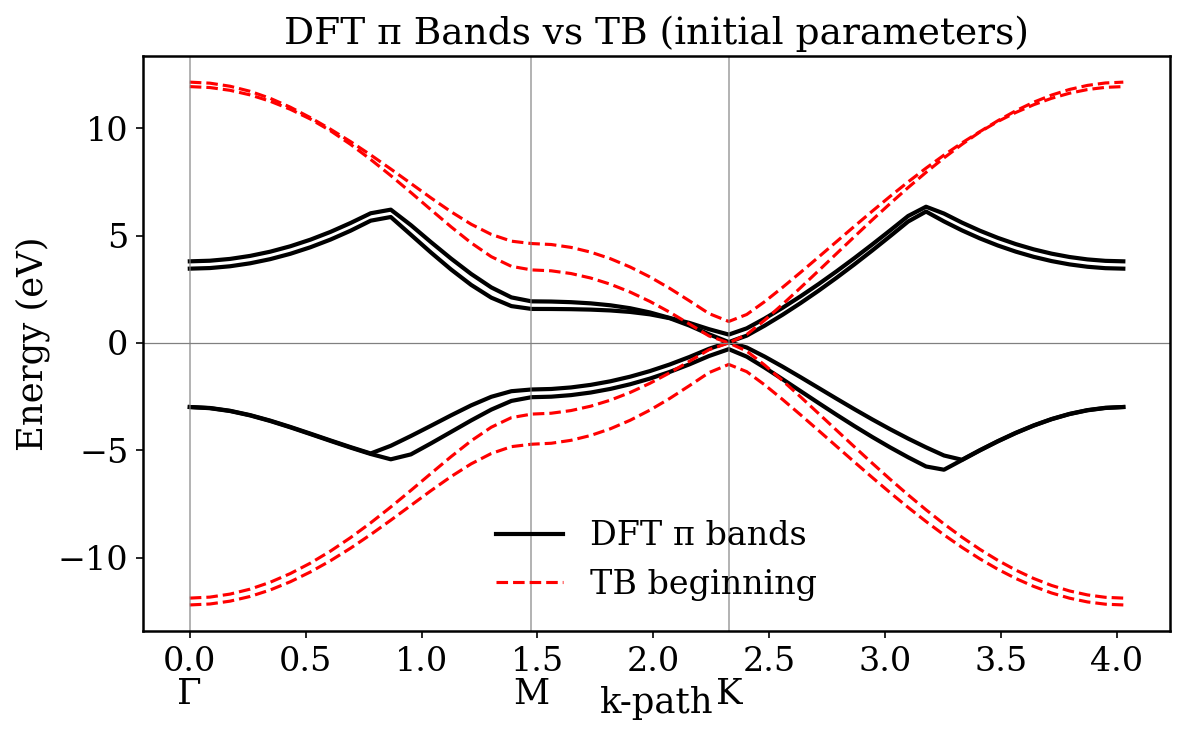

In [9]:
import bandplot


# Compute TB bands:
E_tb_0 = manager.tb_bands(kpts, theta0)

# Number of bands in the DFT π set
nb = E_pi.shape[1]

bands = {
    "DFT π bands": {
        "E": E_pi,         # shape (Nk, nb)
        "color": "k",
        "ls": "-",
        "lw": 2,
    },
    "TB beginning": {
        "E": E_tb_0[:, :nb],   # match π bands only
        "color": "r",
        "ls": "--",
        "lw": 1.5,
    }
}

bandplot.plot_bands(kpts, bands,
                    title="DFT π Bands vs TB (initial parameters)", special_points=sp_idx)


Now fit the TB bands to the DFT bands.

In [11]:
import tb_parameters_optimizer
importlib.reload(tb_parameters_optimizer)

E_pi_ordered = E_pi[:, [2, 0, 1, 3]] # IMPORTANT! Must reorder bands so that they match from the two models.

theta_fit, theta_err = tb_parameters_optimizer.optimize(manager, theta0, kpts, E_pi_ordered, 1.75, 3)


   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         3.7594e+01                                    4.71e+01    
       1              3         4.7374e+00      3.29e+01       1.03e+00       1.34e+01    
       2              5         1.3450e+00      3.39e+00       5.17e-01       4.44e-01    
       3              8         1.3323e+00      1.27e-02       6.46e-02       5.35e-02    
       4              9         1.3279e+00      4.40e-03       1.29e-01       3.05e-01    
       5             10         1.3267e+00      1.17e-03       1.52e-01       1.42e-01    
       6             11         1.3220e+00      4.79e-03       3.80e-02       4.44e-02    
       7             12         1.3209e+00      1.10e-03       7.60e-02       4.29e-02    
       8             13         1.3207e+00      1.23e-04       4.69e-02       1.30e-02    
       9             14         1.3205e+00      2.03e-04       1.17e-02       8.20e-03    

Now plot.

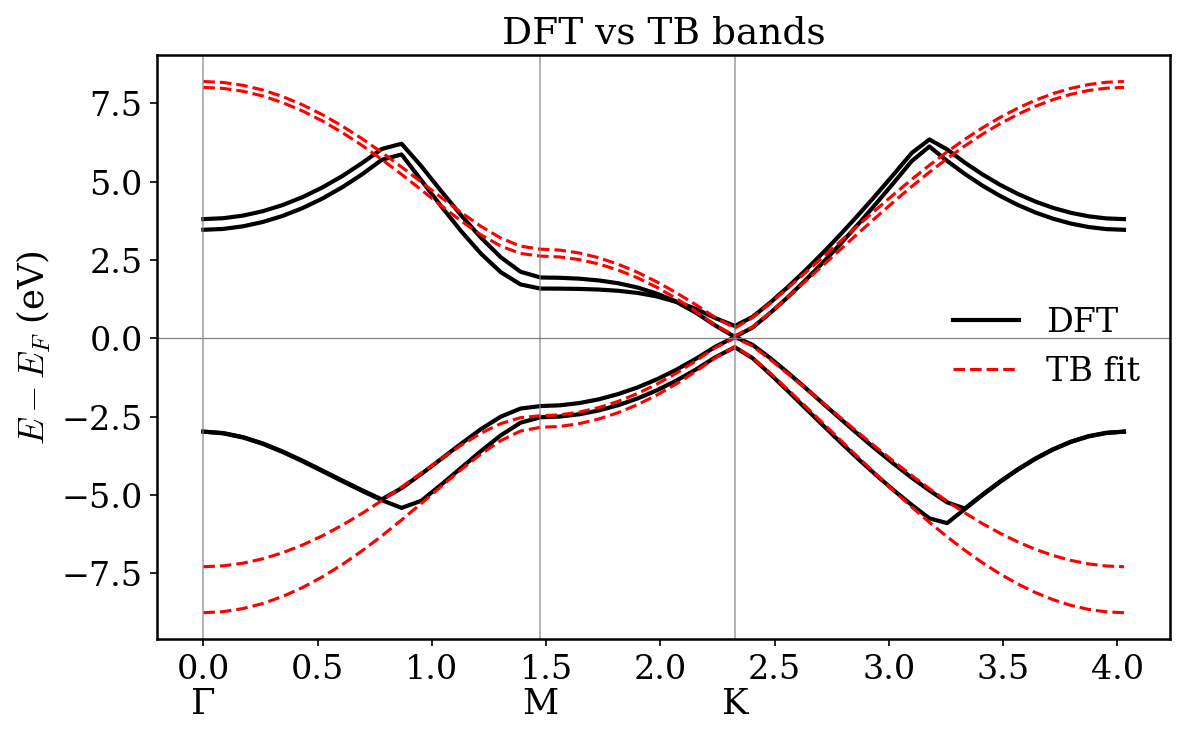

In [12]:

import numpy as np
from common.mpl_style import set_mpl_style
set_mpl_style()

dk = np.sqrt(np.sum(np.diff(kpts, axis=0)**2, axis=1))
x = np.concatenate([[0], np.cumsum(dk)])
E_tb_0 = manager.tb_bands(kpts, theta0)
E_tb_fit = manager.tb_bands(kpts, theta_fit)


from bandplot import plot_bands

bands = {
    "DFT": {
        "E": E_pi,
        "color": "k",
        "ls": "-",
        "lw": 2
    },
    # "TB initial parameters": {
    #     "E": E_tb_0,
    #     "color": "b",
    #     "ls": "-",
    #     "lw": 1.2
    # },
    "TB fit": {
        "E": E_tb_fit,
        "color": "r",
        "ls": "--",
        "lw": 1.5
    }
}

plot_bands(kpts, bands, title="DFT vs TB bands", ylabel=r'$E - E_F$ (eV)', xlabel='', special_points=sp_idx, outfile='../data/fit_result.png')


We try to run the same model but with Hubbard interactions.

In [13]:
from tb_bands_u import TBBandManagerU # Hubbard interactions

manageru = TBBandManagerU(atoms)
manageru.U = 10
manageru.n_mf = np.array([0.1, 0.1, 0.1, 0.1])#np.array([0.52, 0.48, 0.46, 0.54])
E_tb_u = manageru.tb_bands(kpts, theta_fit)

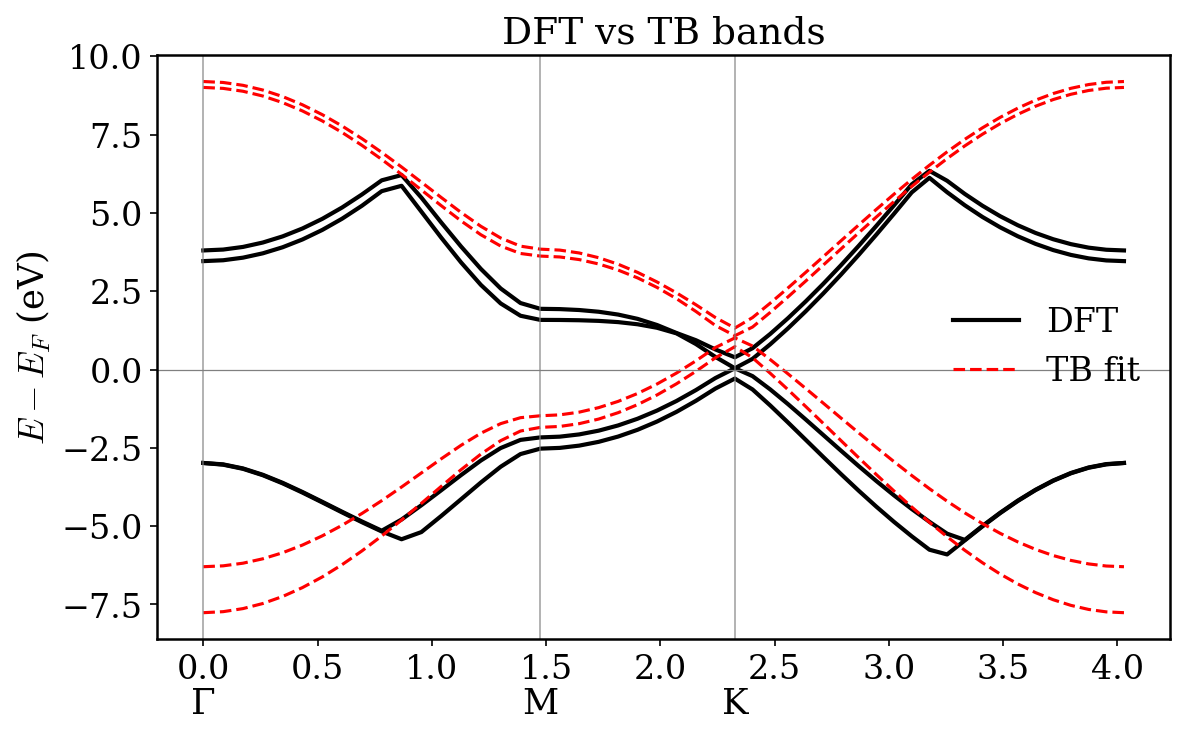

In [14]:
nb = E_pi.shape[1]
bands = {
    "DFT": {
        "E": E_pi,
        "color": "k",
        "ls": "-",
        "lw": 2
    },
    # "TB initial parameters": {
    #     "E": E_tb_0,
    #     "color": "b",
    #     "ls": "-",
    #     "lw": 1.2
    # },
    "TB fit": {
        "E": E_tb_u,
        "color": "r",
        "ls": "--",
        "lw": 1.5
    }
}

plot_bands(kpts, bands, title="DFT vs TB bands", ylabel=r'$E - E_F$ (eV)', xlabel='', special_points=sp_idx, outfile='../data/fit_result.png')

Clearly $U=0$.

## Zoom in
Now we want to zoom in to see the result. We need to run it aroudn the K point with a much bigger zoom.

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
%reload_ext autoreload

In [16]:
from extract_pi_dft_bands import save_pi_dft_bands
save_pi_dft_bands(atoms, calc, path=['M', 'K', 'G'], npoints=200, zoom_label='K', zoom_distance=0.5)

Going to get distance 0.5 around K
Current kpath [[ 0.38131313 -0.23737374  0.        ]
 [ 0.37878788 -0.24242424  0.        ]
 [ 0.37626263 -0.24747475  0.        ]
 [ 0.37373737 -0.25252525  0.        ]
 [ 0.37121212 -0.25757576  0.        ]
 [ 0.36868687 -0.26262626  0.        ]
 [ 0.36616162 -0.26767677  0.        ]
 [ 0.36363636 -0.27272727  0.        ]
 [ 0.36111111 -0.27777778  0.        ]
 [ 0.35858586 -0.28282828  0.        ]
 [ 0.35606061 -0.28787879  0.        ]
 [ 0.35353535 -0.29292929  0.        ]
 [ 0.3510101  -0.2979798   0.        ]
 [ 0.34848485 -0.3030303   0.        ]
 [ 0.3459596  -0.30808081  0.        ]
 [ 0.34343434 -0.31313131  0.        ]
 [ 0.34090909 -0.31818182  0.        ]
 [ 0.33838384 -0.32323232  0.        ]
 [ 0.33585859 -0.32828283  0.        ]
 [ 0.33333333 -0.33333333  0.        ]
 [ 0.33082707 -0.33082707  0.        ]
 [ 0.3283208  -0.3283208   0.        ]
 [ 0.32581454 -0.32581454  0.        ]
 [ 0.32330827 -0.32330827  0.        ]
 [ 0.32080201 -

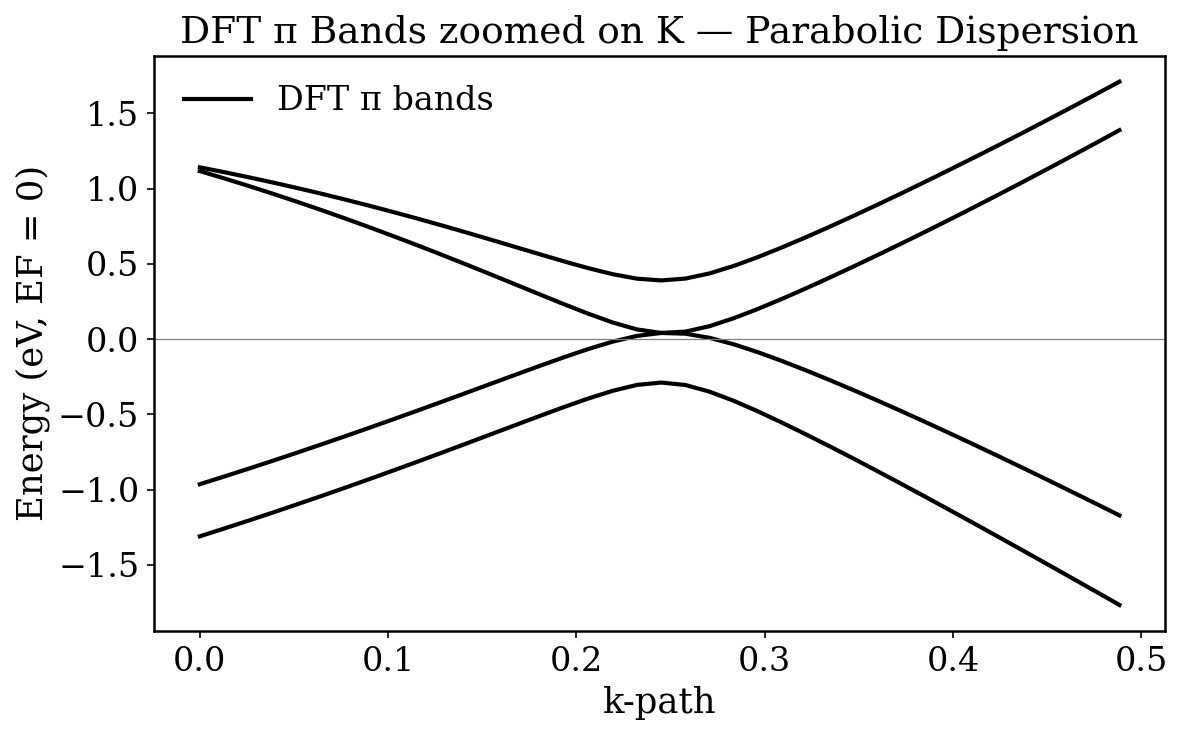

In [17]:
from bandplot import plot_bands
from extract_pi_dft_bands import load_pi_dft_bands

# Load the zoomed bands
kpts_zoom, band_energies_zoom, band_indices_zoom, EF_zoom, sp_idx_zoom, sp_label_zoom = load_pi_dft_bands()

# Number of π bands in zoom region
nb = band_energies_zoom.shape[1]

# Build dataset dictionary
bands = {
    "DFT π bands": {
        "E": band_energies_zoom,   # shape (Nk, nb)
        "color": "k",
        "ls": "-",
        "lw": 2,
    }
}

# Plot
plot_bands(
    kpts_zoom,
    bands,
    title="DFT π Bands zoomed on K — Parabolic Dispersion",
    ylabel="Energy (eV, EF = 0)"
)


Notice the parabolic curve, which is expected.

## DFT DOS


In [18]:
import matplotlib.pyplot as plt
import numpy as np

In [19]:
e, dos = calc.get_dos(spin=0, npts=2001, width=0.2)

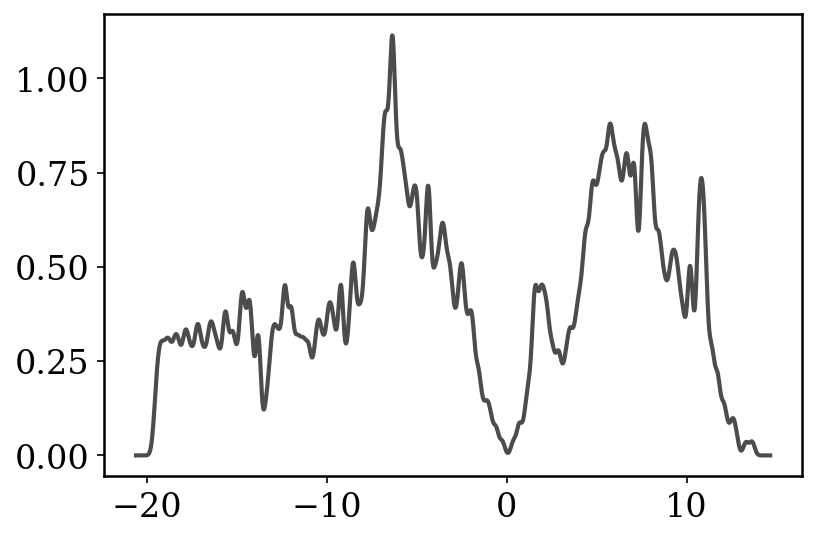

In [20]:
plt.plot(e - EF, dos, label='Total', c='k', lw=2, alpha=0.7)

In [21]:
dist = abs(E_pi.mean(axis=0) - EF)
idx_pi = np.argsort(dist)[:4]   # 4 π bands in bilayer
print("π-band indices:", idx_pi)


π-band indices: [0 2 1 3]


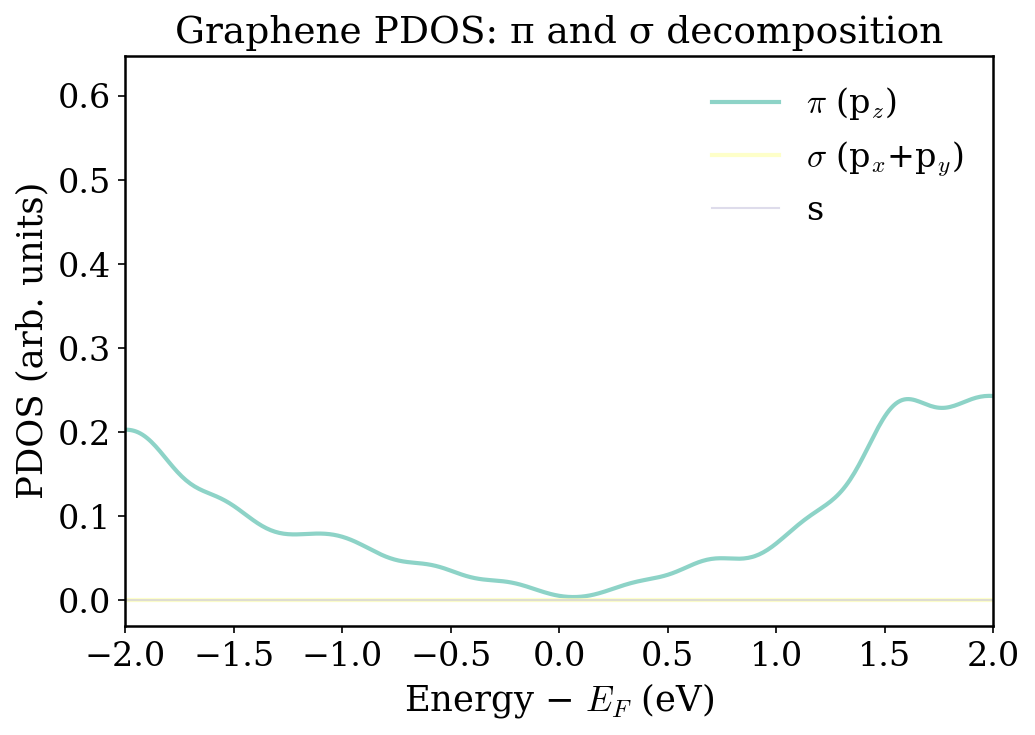

Saved interactive PDOS to: ../data/graphene_pdos_interactive.html


In [22]:
from pdos_plotter import plot_pdos_pi_sigma
import importlib
import pdos_plotter

importlib.reload(pdos_plotter)
# assuming you already have:
# atoms, calc = restart('yourfile.gpw')
plot_pdos_pi_sigma(calc, atoms, atom_indices=[0,1,2,3,], zoom=(-2, 2), save_html=True)

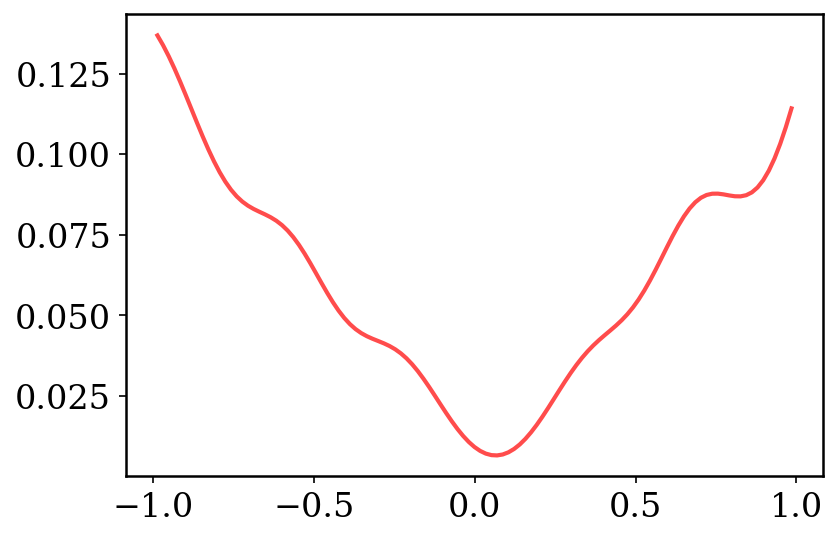

In [23]:
e_min_EF = e - EF
filter = (e_min_EF > -1) & (e_min_EF < 1)
plt.plot(e_min_EF[filter], dos[filter], label='Band', c='r', lw=2, alpha=0.7)

In [24]:
print(f'The minimum value reached by the DOS is {dos[filter].min()} at k={dos[filter].argmin()}')

The minimum value reached by the DOS is 0.006618160771625483 at k=60


## Trigonal warping

In [ ]:
import importlib
import trigonal_warping

from gpaw import restart
from trigonal_warping import (
    compute_patch_bands,
    find_pi_bands,
    plot_trigonal_warping,
    plot_trigonal_warping_3d
)

To observe trigonal warping, we need to generate a patch around the K point. The patch need to be very zoomed in in order to properly observe the effect.

In [ ]:
# Load your converged bilayer AB calc
atoms, calc = restart("../gpw/ab.gpw")
Nq=41
# 1) Compute dense patch around K
qx, qy, E_shifted, EF = compute_patch_bands(
    calc,
    atoms,
    radius=0.006, #0.012   # try 0.03, then maybe smaller like 0.015
    Nq=Nq,         # 41–81 is reasonable
    #nbands=None,  # or explicitly if needed
    txt="tw_blg_patch.txt"
)


going to generate bandpath
generated bandpath
Starting to compute the energies...


Trigonal warping can first be observed by plotting iso contours.

In [ ]:
# # 2) Select the lowest-energy conduction band (or two bands closest to EF)
# #idx, E_low = select_low_energy_bands(E_shifted, n_bands=16)
# #print("Low-energy band indices near EF:", idx)
# #BE_low = E_shifted[:4]
# import numpy as np
# idx_pi, E_pi = find_pi_bands(E_shifted, n=4)
#
# print("π-band indices (closest to EF):", idx_pi)
#
#
# avg_pi = E_pi.mean(axis=(0,1))
#
# # select entries > 0 (conduction)
# pos = np.where(avg_pi > 0)[0]
#
# if len(pos) == 0:
#     raise RuntimeError("No positive-energy π conduction band found!")
#
# # choose the conduction π band closest to zero
# cond_idx_local = pos[np.argmin(avg_pi[pos])]
#
# E_cond = E_pi[..., cond_idx_local]
# print("Using conduction π band:", idx_pi[cond_idx_local])


In [ ]:
# ix0, iy0 = E_cond.shape[0] // 2, E_cond.shape[1] // 2
# print("E_cond at K (center) =", E_cond[ix0, iy0], "eV")


In [ ]:
# at K
E_center = E_shifted[Nq//2, Nq//2, :]
eps = np.abs(E_center)

# find the (positive) π band: smallest positive energy
candidates = np.where(E_center > 0)[0]
cond_idx = candidates[np.argmin(E_center[candidates])]


In [ ]:
E_cond = E_shifted[..., cond_idx]


In [59]:
E_shifted.shape

(31, 31, 14)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# E_cond: (Nq, Nq) conduction π band, shifted so EF=0
# qx, qy: (Nq, Nq) mesh (scaled around K)

plt.figure(figsize=(5, 5))

# choose a few low energies in eV
levels = [0.03, 0.035, 0.04]
cs = plt.contour(qx, qy, E_cond, levels=levels, colors=['b', 'g', 'r'])
plt.clabel(cs, inline=True, fontsize=8, fmt="%.3f eV")

plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.gca().set_aspect('equal', 'box')

plt.xlabel(r"$q_x$ (scaled)")
plt.ylabel(r"$q_y$ (scaled)")
plt.title("Constant-energy contours of π conduction band near K")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Finally, the 3D plot.

In [ ]:
plot_trigonal_warping_3d(
    qx,
    qy,
    E_cond,
    #E_shifted[:, :, 8],
    #E_pi[:, :, 1],
   # title=f"Trigonal warping near K (band {idx[0]})",
    zlim=(0.039, 0.043),  # in eV
    save_html=True,
    html_path="../data/trigonal_warping_3d.html",
    tick_fontsize=17,
    title_fontsize=25,
    axis_title_fontsize=30
)

## Now see if trigonal warping can be observed in the TB model.

In [ ]:
from ase.dft.kpoints import kpoint_convert
from trigonal_warping import make_k_patch_around_K
kpts_patch, qx, qy = make_k_patch_around_K(atoms, radius=0.06, Nq=100)

k_point = kpoint_convert(atoms.cell, skpts_kc=bp.special_points['K'])
k_point_x, k_point_y = k_point[0], k_point[1]
qx, qy = qx + k_point_x, qy + k_point_y

Nq = qx.shape[0]

kpts_flat = np.column_stack([qx.ravel(), qy.ravel()])
from ase.dft.kpoints import get_bandpath, BandPath
bp: BandPath = get_bandpath(['G', 'K', 'M'], atoms.cell)


theta_2 = theta_fit
#theta_2[2] = -0.17#0.35 # update gamma3
theta_2[2] = 2.1
E_tb_flat = manager.tb_bands(kpts_flat, theta_2)
E_tb_grid = E_tb_flat.reshape(Nq, Nq, 4)

In [ ]:
E_tb_0, E_tb_1 = E_tb_grid[:, :, 0], E_tb_grid[:, :, 2]
E_max = np.maximum(E_tb_0, E_tb_1)   # shape (Nq, Nq)

In [ ]:
import trigonal_warping
import importlib
importlib.reload(trigonal_warping)
E_center = E_tb_grid[Nq // 2, Nq // 2, :]
eps = np.abs(E_center)




trigonal_warping.plot_trigonal_warping_3d(
    qx,
    qy,
    E_tb_grid[:, :, 1],
    zlim=(-0.02, 0.1),
    save_html=True,
    html_path="../data/tb_trigonal_warping_3d.html",
    tick_fontsize=17,
    title_fontsize=25,
    axis_title_fontsize=30
)